graph data prep & machine learning (using emabdding and nn)

In [44]:
import numpy as np
import pandas as pd
import porespy as ps
import openpnm as op
import networkx as nx
import tensorflow as tf
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from node2vec import Node2Vec

np.random.seed(10)

In [45]:
def calculate_permeability(pn, shape, resolution):
    pn['pore.diameter'] = pn['pore.equivalent_diameter']
    pn['throat.diameter'] = pn['throat.inscribed_diameter']
    pn['throat.spacing'] = pn['throat.total_length']

    # Add viscosity to the throats before calculating hydraulic conductance
    pn['throat.viscosity'] = 1.0  # Assign a viscosity value to throats

    pn.add_model(propname='throat.hydraulic_size_factors',
                 model=op.models.geometry.hydraulic_size_factors.pyramids_and_cuboids)
    pn.add_model(propname='throat.diffusive_size_factors',
                 model=op.models.geometry.diffusive_size_factors.pyramids_and_cuboids)
    pn['throat.hydraulic_conductance'] = pn['throat.diameter']**2 * np.pi / (128 * pn['throat.viscosity'] * pn['throat.spacing'])
    pn.regenerate_models()

    gas = op.phase.Phase(network=pn)
    gas['pore.diffusivity'] = 1.0
    gas['pore.viscosity'] = 1.0
    gas['throat.entry_pressure'] = 0
    gas['throat.surface_tension'] = 1.0
    gas['throat.contact_angle'] = 0

    gas.add_model(propname="pore.viscosity", model=op.models.misc.constant, value=1.0)
    gas.add_model(propname="pore.diffusivity", model=op.models.misc.constant, value=1.0)
    gas.add_model(propname="throat.diffusive_conductance", model=op.models.misc.constant, value=1.0)

    # Set boundary conditions and run Stokes flow
    sf = op.algorithms.StokesFlow(network=pn, phase=gas)
    sf.set_value_BC(pores=pn.pores('xmin'), values=1.0)
    sf.set_value_BC(pores=pn.pores('xmax'), values=0.0)
    sf.run()

    # Calculate permeability
    dP = 1.0
    L = (shape + 6) * resolution
    A = shape * shape * resolution**2
    K = sf.rate(pores=pn.pores('xmin')) * (L / A) / dP * 1e12

    # DELETE THIS LINE EVENTUALLY:
    K[0] = np.log10(K[0])
    return K[0]

In [46]:
import porespy as ps
import numpy as np

shape = 5  # Or whatever shape you are using

try:
    rock_image = ps.generators.blobs(shape=[shape,shape,shape], porosity=0.6, blobiness=2)
    rock_network_results = ps.networks.snow2(rock_image, voxel_size=1)
    network_dict = rock_network_results.network

    # Your code that might be causing the error, e.g.,
    throat_conns = network_dict['throat.conns']
    for i in range(len(throat_conns)):
        pore1, pore2 = throat_conns[i] # This might be the line

    # ... rest of your code ...

except IndexError as e:
    print(f"IndexError: {e}")
    if 'network' in locals() and network_dict is not None:
        print("Contents of rock_network.network when error occurred:")
        for key, value in network_dict.items():
            print(f"{key}: shape={getattr(value, 'shape', None)}, dtype={getattr(value, 'dtype', None)}")

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

IndexError: index 8 is out of bounds for axis 0 with size 8


In [47]:
data = []
for i in range(20):
    shape = 20
    resolution = 5e-6
    rock_image = ps.generators.blobs(shape=[shape,shape,shape], porosity=0.6, blobiness=2)
    rock_network = ps.networks.snow2(rock_image, voxel_size=1)

    pnm_net = op.io.network_from_porespy(rock_network.network)
    graph = op.io.network_to_networkx(pnm_net)
    data.append([graph, calculate_permeability(pnm_net, shape, resolution)])

print(data)
import pickle
with open("array.pkl", 'wb') as file: pickle.dump(data, file)

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

...

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

Extracting pore and throat properties:   0%|          | 0/23 [00:00<?, ?it/s]

Exception: Your network is clustered, making Ax = b ill-conditioned

In [71]:
def generate_embeddings(graph, dimensions=128, walk_length=30, num_walks=200, window_size=10, workers=4):
    """Generate node2vec embeddings for a single graph."""
    node2vec = Node2Vec(
        graph, 
        dimensions=dimensions, 
        walk_length=walk_length, 
        num_walks=num_walks, 
        workers=workers
    )
    
    model = node2vec.fit(window=window_size, min_count=1, batch_words=4)
    embedding = np.mean([model.wv[str(node)] for node in graph.nodes], axis=0)
    return embedding

embeddings = np.array([generate_embeddings(graph) for graph, _ in data])
permeability = np.array([item[1] for item in data])

Computing transition probabilities:   0%|          | 0/31 [00:00<?, ?it/s]

Computing transition probabilities:   0%|          | 0/28 [00:00<?, ?it/s]

Computing transition probabilities:   0%|          | 0/28 [00:00<?, ?it/s]

Computing transition probabilities:   0%|          | 0/30 [00:00<?, ?it/s]

Computing transition probabilities:   0%|          | 0/22 [00:00<?, ?it/s]

...

Computing transition probabilities:   0%|          | 0/32 [00:00<?, ?it/s]

Computing transition probabilities:   0%|          | 0/33 [00:00<?, ?it/s]

Computing transition probabilities:   0%|          | 0/31 [00:00<?, ?it/s]

Computing transition probabilities:   0%|          | 0/28 [00:00<?, ?it/s]

Computing transition probabilities:   0%|          | 0/21 [00:00<?, ?it/s]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(embeddings)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, permeability, test_size=0.2, random_state=42)

In [101]:
print(f"Max embedding value: {np.max(X_scaled)}")
print(f"Min embedding value: {np.min(X_scaled)}")

Max embedding value: 2.7563164234161377
Min embedding value: -2.945483446121216


In [98]:
print(X_train)

[[ 1.1425143  -1.8535569  -0.2773146  ...  1.241661    1.5366588
   1.5691626 ]
 [-0.5227919   0.3571144  -0.14142671 ... -0.28248054 -0.521475
   0.64345914]
 [-1.3004061   0.9178419  -0.49973053 ...  0.04542167  0.22667028
  -0.16557716]
 ...
 [ 0.46589583 -0.7865195   1.2519274  ... -0.5026516  -1.2382586
  -1.8248556 ]
 [ 0.88012975 -0.77561206  1.6203312  ...  1.0886214  -0.5432701
   0.53017044]
 [-1.5031937   1.4098474  -1.5782275  ... -2.504133   -1.6776756
  -1.2870806 ]]


In [99]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Fit the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
y_pred = lr_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.4f}")


C:\Users\amkah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\_array_api.py:839: RuntimeWarning: overflow encountered in cast
  array = numpy.asarray(array, order=order, dtype=dtype)


ValueError: Input contains infinity or a value too large for dtype('float32').

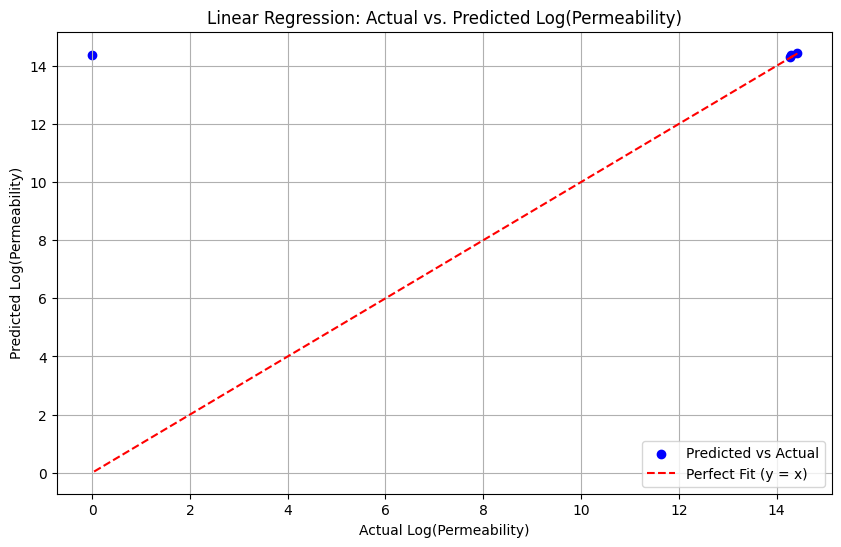

In [61]:
plt.figure(figsize=(10, 6))

# Scatter plot of actual vs. predicted values
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')

# Plotting the perfect fit line (y = x) for reference
plt.plot(y_test, y_test, color='red', label='Perfect Fit (y = x)', linestyle='--')

# Labels and legend
plt.xlabel('Actual Log(Permeability)')
plt.ylabel('Predicted Log(Permeability)')
plt.title('Linear Regression: Actual vs. Predicted Log(Permeability)')
plt.legend()
plt.grid(True)
plt.show()


In [41]:
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),  # Add dropout to prevent overfitting
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)  # Output layer for regression
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse', metrics=['mae']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/100


C:\Users\amkah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 204.5383 - mae: 14.2941 - val_loss: nan - val_mae: nan - learning_rate: 0.0010
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - loss: 184.9348 - mae: 13.5905 - val_loss: nan - val_mae: nan - learning_rate: 0.0010
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - loss: 167.5700 - mae: 12.9363 - val_loss: nan - val_mae: nan - learning_rate: 0.0010
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - loss: 153.2240 - mae: 12.3663 - val_loss: nan - val_mae: nan - learning_rate: 0.0010
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - loss: 139.1138 - mae: 11.7729 - val_loss: nan - val_mae: nan - learning_rate: 0.0010
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - loss: 123.1494 - mae: 11.0712 - val_loss: nan - val_mae: nan - learning_rate: 5.0000e-04
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - loss: 113.2902 - mae: 10.5877 - val_loss: nan - val_mae: nan - learning_rate: 5.0000e-04
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2

In [42]:
loss, mae = model.evaluate(X_test, y_test)
print(f"Test MAE: {mae}")
predictions = model.predict(X_test)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: nan - mae: nan
Test MAE: nan
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
